In [26]:
do = False # @param{type:"boolean"}
if do:
    %pip install torchinfo -qq
    %pip install -U git+https://github.com/qubvel/segmentation_models.pytorch -qq
    %pip install starfile -qq
    %pip install https://github.com/soft-matter/trackpy/archive/master.zip -qq

In [27]:
if do:
    !git clone https://github.com/phonchi/CryoParticleSegment.git

    !wget -O /content/CryoParticleSegment/Modeling/convcrf.py https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/adjusted_modeling/convcrf.py
    !wget -O /content/CryoParticleSegment/Modeling/dataset.py https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/adjusted_modeling/dataset.py
    !wget -O /content/CryoParticleSegment/Modeling/model.py https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/adjusted_modeling/model.py
    !wget -O /content/CryoParticleSegment/Modeling/trainer.py https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/adjusted_modeling/trainer.py

In [28]:
import sys
import os

# Adjust the path relative to your current working directory
module_path = os.path.abspath('CryoParticleSegment/Modeling')

# Add to sys.path if it's not already included
if module_path not in sys.path:
    sys.path.append(module_path)

In [29]:
if do:
    #%git clone https://github.com/netw0rkf10w/CRF.git
    %cd CryoParticleSegment/Modeling/CRF_main
    !python setup.py clean --all
    !rm -rf build/
    !python setup.py build_ext --inplace --force
    !python setup.py install

In [30]:
if do:
    %pip install pycuda==2024.1
    %pip install "numpy<2.0"
    %pip install mrcfile -qq

In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
# @title  { display-mode: "form" }

IMAGE_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/dataset/10017/processed_micrographs_np_split" # @param {type:"string"}
LABEL_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output/dataset/10017/micrographs_ground_np" # @param {type:"string"}
RESULT_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/results_100_CDF/10017/unet_eb5_dice_CRF" # @param {type:"string"}
%cd /content/

import os
if "content" in IMAGE_DIR.split("/")[:3] or "content" in LABEL_DIR.split("/")[:3]:
  try:
    from google.colab import drive
    drive.mount('/content/drive')
    !rm -r /content/sample_data
    if not os.path.exists("/content/image_dir"):
        if "content" in LABEL_DIR.split("/")[:3]:
            !cp -r {LABEL_DIR} /content/label_dir
            LABEL_DIR = "/content/label_dir"
  except:
    pass

%cd /content/

/content
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
rm: cannot remove '/content/sample_data': No such file or directory
/content


In [33]:
# @title  { display-mode: "form" }
# @markdown Useful packages.

import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau, OneCycleLR
import gc
from tqdm import tqdm

In [34]:
# @title  { display-mode: "form" }
# @markdown User-defined packages.

from dataset import MicrographDataset, MicrographDatasetEvery
from dataset import reconstruct_patched, collate_fn
from model import create_model
from trainer import CryoEMEvaluator
from trainer import CryoEMTrainerWithScheduler, tqdm_plugin_for_Trainer

In [35]:
def simple_micrograph_preprocessing(micrograph):
    micrograph_copy = micrograph.copy()
    micrograph_copy = (micrograph_copy-micrograph.mean()+2.5*micrograph.std())/5/micrograph.std()
    micrograph_copy[micrograph_copy<0]=0
    micrograph_copy[micrograph_copy>1]=1
    return micrograph_copy

def normalize(im):
    max_mrc=np.max(im)
    min_mrc=np.min(im)
    img_original=(255*((im-min_mrc)/(max_mrc-min_mrc))).astype(np.uint8)
    return(img_original)

def preprocess_and_crop(micrograph, crop_size=3840):
    processed_micrograph = simple_micrograph_preprocessing(micrograph)
    if crop_size:
        mic_width, mic_height = processed_micrograph.shape[1], processed_micrograph.shape[0]
        start_x, start_y = (mic_width - crop_size) // 2, (mic_height - crop_size) // 2
        end_x, end_y = start_x + crop_size, start_y + crop_size
        return processed_micrograph[start_y:end_y, start_x:end_x]
    else:
        return processed_micrograph

In [36]:
# @markdown Parameters.

NUM_CLASSES = 2
EPOCHS = 50
BATCH = 8
CROP_SIZE = (512, 512)
LR = 1e-3

RLR_PATIENCE = 3
ES_PATIENCE = 15
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [37]:
# @markdown Set seed.

random_state = 42
torch.manual_seed(random_state)
torch.cuda.manual_seed_all(random_state)

In [38]:
# @title  { display-mode: "form" }

architecture = "Unet++" # @param {type:"string"}
encoder = "timm-efficientnet-b5" # @param {type:"string"}
pretrained = True # @param {type:"boolean"}
solver = "fw" # @param {type:"string"}
use_unary_only = True # @param {type:"boolean"}


In [39]:
import segmentation_models_pytorch as smp

if pretrained:
  weights = "imagenet"
else:
  weights = None

if architecture == "Unet++":
    backbone = smp.UnetPlusPlus(
        encoder_name=encoder,        # choose encoder, densenet201, resnet50, e.g. mobilenet_v2 or efficientnet-b5
        encoder_weights=weights,     # use `imagenet` or `advprop` for pre-trained weights for encoder initialization
        in_channels=1,                  # model input channels (1 for gray-scale images, 3 for RGB, etc.)
        classes=2,                      # model output channels (number of classes in your dataset)
    )

elif architecture == "Deeplab":
    backbone = smp.DeepLabV3(
        encoder_name=encoder,        # choose encoder, densenet201, resnet50, e.g. mobilenet_v2 or efficientnet-b5
        encoder_weights=weights,     # use `imagenet` pre-trained weights for encoder initialization
        in_channels=1,                  # model input channels (1 for gray-scale images, 3 for RGB, etc.)
        classes=2,                      # model output channels (number of classes in your dataset)
    )
else:
    print("Architecture not supported")
    raise NotImplementedError

model = create_model(backbone, addout=True) #crf_args

In [40]:
import CRF
import torch.nn as nn
from model import setup_crf, create_fwcrf_model

# Example usage
solver = 'fw'  # Assuming the solver type is defined

crf = setup_crf(solver, NUM_CLASSES)
model_post = create_fwcrf_model(model.backbone, crf, use_unary_only=True)

CRF solver: fw
x0_weight: 0.0
FrankWolfeParams: 
	 scheme:	 fixed 
	 stepsize:	 1.0 (for the 'fixed' scheme) 
	 regularizer:	 l2
	 lambda_:	 1.0
	 lambda_learnable:	 False
	 x0_weight:	 0.5
	 x0_weight_learnable:	 False
Non-trainable lambda for Frank-Wolfe: 1.0
Non-trainable x0_weight for Frank-Wolfe: 0.5
Potts: remove random weights.
Add 1.0 to spatial_weight diagonal
Add 1.0 to bilateral_weight diagonal
Add -1.0 to compatibility diagonal


In [41]:
# @markdown fcn define
import os
import gc
from typing import Tuple

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import ConcatDataset


def hist_mask_prob(
    image_dir: str,
    label_dir: str,
    result_dir: str,
    model_instance: torch.nn.Module,
    device: torch.device,
    crop_size: tuple,
    num_samples: int = 10,
    mini_batch_size: int = 18,
    random_state: int = 42,
    num_bins: int = 100,
) -> Tuple[np.ndarray, np.ndarray, float]:
    """
    Sample num_samples micrographs at random (from train/val/test lists), run patch-wise
    inference, compute per-micrograph histograms of class-1 probability (bins over [0,1]),
    and plot the mean histogram (with ±1 std). Also prints and returns the ratio:
      ratio = total pixels in [0.49,0.51] / total pixels in [0.40,0.60]
    The data read and dataset construction follow your original pattern; sampling is random.
    """

    # --- 1. Setup datasets and filename lists (same ordering as dataset concat) ---
    train_dir = os.path.join(image_dir, "train")
    val_dir = os.path.join(image_dir, "val")
    test_dir = os.path.join(image_dir, "test")

    train_filenames = np.loadtxt(f"{image_dir}/train_filenames.txt", dtype=str)
    val_filenames = np.loadtxt(f"{image_dir}/val_filenames.txt", dtype=str)
    test_filenames = np.loadtxt(f"{image_dir}/test_filenames.txt", dtype=str)
    full_filenames = np.concatenate((train_filenames, val_filenames, test_filenames))

    train_dataset = MicrographDatasetEvery(image_dir=train_dir, label_dir=label_dir, filenames=train_filenames, crop_size=crop_size)
    val_dataset = MicrographDatasetEvery(image_dir=val_dir, label_dir=label_dir, filenames=val_filenames, crop_size=crop_size)
    test_dataset = MicrographDatasetEvery(image_dir=test_dir, label_dir=None, filenames=test_filenames, crop_size=crop_size)
    full_dataset = ConcatDataset([train_dataset, val_dataset, test_dataset])

    n = len(full_dataset)

    # --- 2. Load model checkpoint (latest .pt) and set eval mode ---
    ckpts = sorted([p for p in os.listdir(result_dir) if p.endswith(".pt")])
    checkpoint_path = ckpts[-1]
    state_dict = torch.load(os.path.join(result_dir, checkpoint_path), map_location=device)
    model_instance.load_state_dict(state_dict, strict=False)
    model_instance.to(device)
    model_instance.eval()

    # --- 3. Random selection of micrographs to sample ---
    rng = np.random.default_rng(random_state)
    sample_indices = rng.choice(n, size=num_samples, replace=False)

    all_counts = []
    total_in_048_052 = 0
    total_in_04_06 = 0

    # Process each sampled micrograph
    for idx in tqdm(sample_indices, desc="Processing sampled micrographs"):
        item = full_dataset[idx]
        # item expected layouts: (images, denoised, masks, grid, orig_mask) or (images, denoised, grid, orig_mask)
        images = item[0]
        grid = item[3] if len(item) >= 5 else item[2]

        # patch-wise inference
        with torch.no_grad():
            inputs = images.to(device)
            n_patches = inputs.size(0)
            num_batches = (n_patches + mini_batch_size - 1) // mini_batch_size
            parts = []
            for b in range(num_batches):
                s = b * mini_batch_size
                e = min(s + mini_batch_size, n_patches)
                out = model_instance(inputs[s:e])['out']   # logits
                parts.append(out.cpu())
                del out
                torch.cuda.empty_cache()

            outputs = torch.cat(parts, dim=0)            # (n_patches, num_classes, h, w)
            probs = F.softmax(outputs, dim=1)
            class1_patches = probs[:, 1, :, :]          # (n_patches, h, w)

            # reconstruct and flatten
            full_prob = reconstruct_patched(class1_patches.unsqueeze(1), grid)
            full_prob_np = full_prob.squeeze().cpu().numpy().ravel()

            # histogram counts for this micrograph
            counts, bin_edges = np.histogram(full_prob_np, bins=num_bins, range=(0.0, 1.0))
            all_counts.append(counts.astype(np.float64))

            # accumulate totals for the two intervals
            total_in_048_052 += int(((full_prob_np >= 0.48) & (full_prob_np <= 0.52)).sum())
            total_in_04_06 += int(((full_prob_np >= 0.40) & (full_prob_np <= 0.60)).sum())

            # cleanup
            del parts, outputs, probs, class1_patches, full_prob, full_prob_np
            torch.cuda.empty_cache()

    # --- 4. Aggregate histograms and plot mean ± std ---
    all_counts = np.stack(all_counts, axis=0)  # (num_samples, num_bins)
    mean_counts = all_counts.mean(axis=0)
    std_counts = all_counts.std(axis=0)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0

    plt.figure(figsize=(10, 5))
    width = bin_edges[1] - bin_edges[0]
    plt.bar(bin_centers, mean_counts, width=width, color='C0', alpha=0.7, label='mean counts')
    plt.fill_between(bin_centers, mean_counts - std_counts, mean_counts + std_counts, color='C0', alpha=0.2, label='±1 std')

    plt.axvline(0.48, color='k', linestyle='--', linewidth=1.2, label='0.48 / 0.52')
    plt.axvline(0.52, color='k', linestyle='--', linewidth=1.2)

    plt.xlabel('Predicted probability (class 1)')
    plt.ylabel('Mean pixel count per bin (across sampled micrographs)')
    plt.ylim((0,100000))
    plt.title(f'Mean histogram of class-1 probabilities over {num_samples} random micrographs')
    plt.legend()
    plt.show()

    ratio = float(total_in_048_052) / float(total_in_04_06) if total_in_04_06 != 0 else float("nan")
    diff_with_baseline = ratio - 5/21
    print(f"Total pixels in [0.48,0.52] (sum over sampled micrographs): {total_in_048_052}")
    print(f"Total pixels in [0.40,0.60] (sum over sampled micrographs): {total_in_04_06}")
    print(f"Ratio [0.48-0.52] / [0.40-0.60] = {ratio:.6f}")
    print(f"Baseline = {5/21:.6f}")
    print(f"Difference with baseline = {diff_with_baseline:.6f}")

    gc.collect()
    torch.cuda.empty_cache()

    return mean_counts, bin_edges, ratio

In [42]:
# @markdown fcn adjusted define

def hist_mask_prob_adjusted(
    image_dir: str,
    denoised_dir: str,
    label_dir: str,
    result_dir: str,
    model_instance: torch.nn.Module,
    device: torch.device,
    crop_size: tuple,
    num_samples: int = 10,
    mini_batch_size: int = 18,
    random_state: int = 42,
    num_bins: int = 100,
) -> Tuple[np.ndarray, np.ndarray, float]:
    """
    Sample num_samples micrographs at random (from train/val/test lists), run patch-wise
    inference, compute per-micrograph histograms of class-1 probability (bins over [0,1]),
    and plot the mean histogram (with ±1 std). Also prints and returns the ratio:
      ratio = total pixels in [0.49,0.51] / total pixels in [0.40,0.60]
    The data read and dataset construction follow your original pattern; sampling is random.
    """

    # --- 1. Setup datasets and filename lists (same ordering as dataset concat) ---
    train_dir = os.path.join(image_dir, "train")
    val_dir = os.path.join(image_dir, "val")
    test_dir = os.path.join(image_dir, "test")

    dnzd_train_dir = os.path.join(image_dir, "train")
    dnzd_val_dir = os.path.join(image_dir, "val")
    dnzd_test_dir = os.path.join(image_dir, "test")

    train_filenames = np.loadtxt(f"{image_dir}/train_filenames.txt", dtype=str)
    val_filenames = np.loadtxt(f"{image_dir}/val_filenames.txt", dtype=str)
    test_filenames = np.loadtxt(f"{image_dir}/test_filenames.txt", dtype=str)
    full_filenames = np.concatenate((train_filenames, val_filenames, test_filenames))

    train_dataset = MicrographDatasetEvery(image_dir=train_dir, label_dir=label_dir, denoised_dir = dnzd_train_dir, filenames=train_filenames, crop_size=crop_size)
    val_dataset = MicrographDatasetEvery(image_dir=val_dir, label_dir=label_dir, denoised_dir = dnzd_val_dir, filenames=val_filenames, crop_size=crop_size)
    test_dataset = MicrographDatasetEvery(image_dir=test_dir, label_dir=None, denoised_dir = dnzd_test_dir, filenames=test_filenames, crop_size=crop_size)
    full_dataset = ConcatDataset([train_dataset, val_dataset, test_dataset])

    n = len(full_dataset)

    # --- 2. Load model checkpoint (latest .pt) and set eval mode ---
    ckpts = sorted([p for p in os.listdir(result_dir) if p.endswith(".pt")])
    checkpoint_path = ckpts[-1]
    state_dict = torch.load(os.path.join(result_dir, checkpoint_path), map_location=device)
    model_instance.load_state_dict(state_dict, strict=False)
    model_instance.to(device)
    model_instance.eval()

    # --- 3. Random selection of micrographs to sample ---
    rng = np.random.default_rng(random_state)
    sample_indices = rng.choice(n, size=num_samples, replace=False)

    all_counts = []
    total_in_048_052 = 0
    total_in_04_06 = 0

    # Process each sampled micrograph
    for idx in tqdm(sample_indices, desc="Processing sampled micrographs"):
        item = full_dataset[idx]
        # item expected layouts: (images, denoised, masks, grid, orig_mask) or (images, denoised, grid, orig_mask)
        images = item[0]
        grid = item[3]
        # grid = item[2]

        # patch-wise inference
        with torch.no_grad():
            inputs = images.to(device)
            n_patches = inputs.size(0)
            num_batches = (n_patches + mini_batch_size - 1) // mini_batch_size
            parts = []
            for b in range(num_batches):
                s = b * mini_batch_size
                e = min(s + mini_batch_size, n_patches)
                out = model_instance(inputs[s:e])['out']   # logits
                parts.append(out.cpu())
                del out
                torch.cuda.empty_cache()

            outputs = torch.cat(parts, dim=0)            # (n_patches, num_classes, h, w)
            probs = F.softmax(outputs, dim=1)
            class1_patches = probs[:, 1, :, :]          # (n_patches, h, w)

            # reconstruct and flatten
            full_prob = reconstruct_patched(class1_patches.unsqueeze(1), grid)
            full_prob_np = full_prob.squeeze().cpu().numpy().ravel()

            # histogram counts for this micrograph
            counts, bin_edges = np.histogram(full_prob_np, bins=num_bins, range=(0.0, 1.0))
            all_counts.append(counts.astype(np.float64))

            # accumulate totals for the two intervals
            total_in_048_052 += int(((full_prob_np >= 0.48) & (full_prob_np <= 0.52)).sum())
            total_in_04_06 += int(((full_prob_np >= 0.40) & (full_prob_np <= 0.60)).sum())

            # cleanup
            del parts, outputs, probs, class1_patches, full_prob, full_prob_np
            torch.cuda.empty_cache()

    # --- 4. Aggregate histograms and plot mean ± std ---
    all_counts = np.stack(all_counts, axis=0)  # (num_samples, num_bins)
    mean_counts = all_counts.mean(axis=0)
    std_counts = all_counts.std(axis=0)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0

    plt.figure(figsize=(10, 5))
    width = bin_edges[1] - bin_edges[0]
    plt.bar(bin_centers, mean_counts, width=width, color='C0', alpha=0.7, label='mean counts')
    plt.fill_between(bin_centers, mean_counts - std_counts, mean_counts + std_counts, color='C0', alpha=0.2, label='±1 std')

    plt.axvline(0.48, color='k', linestyle='--', linewidth=1.2, label='0.48 / 0.52')
    plt.axvline(0.52, color='k', linestyle='--', linewidth=1.2)

    plt.xlabel('Predicted probability (class 1)')
    plt.ylabel('Mean pixel count per bin (across sampled micrographs)')
    plt.ylim((0,100000))
    plt.title(f'Mean histogram of class-1 probabilities over {num_samples} random micrographs')
    plt.legend()
    plt.show()

    ratio = float(total_in_048_052) / float(total_in_04_06) if total_in_04_06 != 0 else float("nan")
    diff_with_baseline = ratio - 5/21
    print(f"Total pixels in [0.48,0.52] (sum over sampled micrographs): {total_in_048_052}")
    print(f"Total pixels in [0.40,0.60] (sum over sampled micrographs): {total_in_04_06}")
    print(f"Ratio [0.48-0.52] / [0.40-0.60] = {ratio:.6f}")
    print(f"Baseline = {5/21:.6f}")
    print(f"Difference with baseline = {diff_with_baseline:.6f}")

    gc.collect()
    torch.cuda.empty_cache()

    return mean_counts, bin_edges, ratio

---
00

In [43]:
IMAGE_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/dataset/10017/processed_micrographs_np_split" # @param {type:"string"}
DENOISED_IMAGE_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/dataset/10017/processed_micrographs_np_split" # @param {type:"string"}
RESULT_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/results_with_denoise_reference_CRF/10017/unet_eb5_dice" # @param {type:"string"}


Processing sampled micrographs: 100%|██████████| 10/10 [00:36<00:00,  3.65s/it]


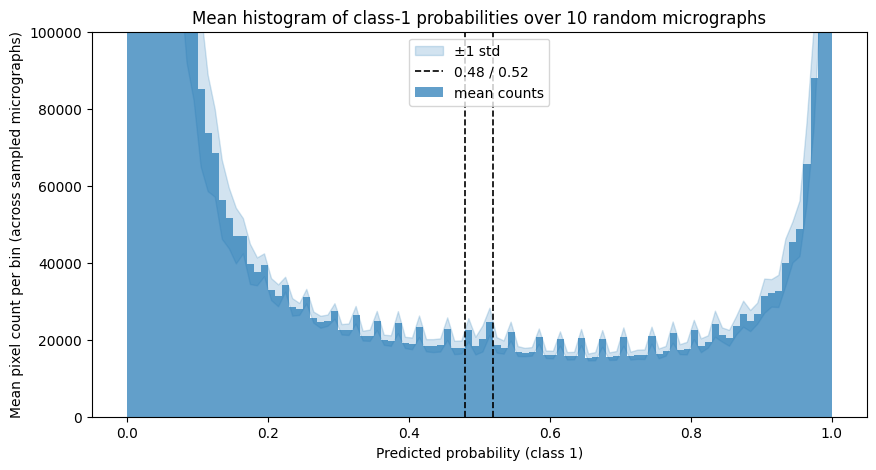

Total pixels in [0.48,0.52] (sum over sampled micrographs): 856469
Total pixels in [0.40,0.60] (sum over sampled micrographs): 3877119
Ratio [0.48-0.52] / [0.40-0.60] = 0.220903
Baseline = 0.238095
Difference with baseline = -0.017192


In [44]:
a = hist_mask_prob_adjusted(
     image_dir=IMAGE_DIR,
     denoised_dir=DENOISED_IMAGE_DIR,
     label_dir=LABEL_DIR,
     result_dir=RESULT_DIR,
     model_instance=model,
     device=device,
     crop_size=CROP_SIZE,
)

In [45]:
IMAGE_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/dataset/10017/processed_micrographs_np_split" # @param {type:"string"}
DENOISED_IMAGE_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/dataset/10017/processed_micrographs_np_split" # @param {type:"string"}
RESULT_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/results_with_denoise_reference_CRF/10017/unet_eb5_dice_CRF" # @param {type:"string"}


Processing sampled micrographs: 100%|██████████| 10/10 [00:36<00:00,  3.64s/it]


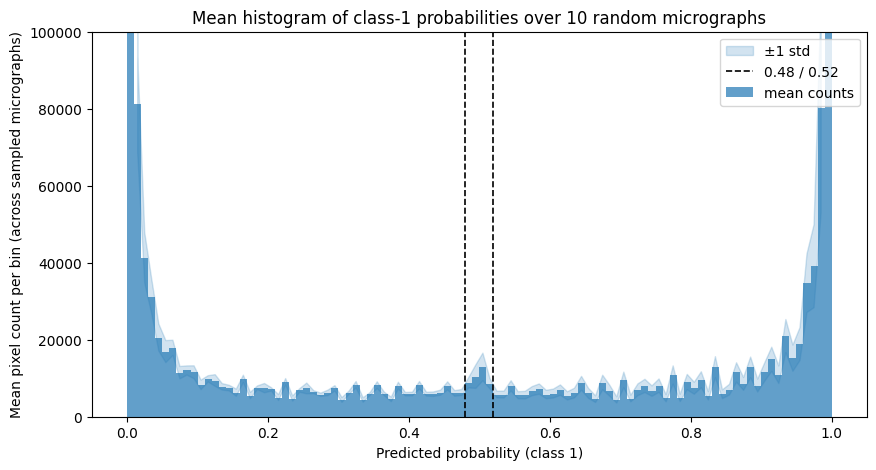

Total pixels in [0.48,0.52] (sum over sampled micrographs): 407648
Total pixels in [0.40,0.60] (sum over sampled micrographs): 1433898
Ratio [0.48-0.52] / [0.40-0.60] = 0.284294
Baseline = 0.238095
Difference with baseline = 0.046198


In [46]:
a = hist_mask_prob_adjusted(
     image_dir=IMAGE_DIR,
     denoised_dir=DENOISED_IMAGE_DIR,
     label_dir=LABEL_DIR,
     result_dir=RESULT_DIR,
     model_instance=model,
     device=device,
     crop_size=CROP_SIZE,
)

---

### 1-1-1 raw 01 epoch 100 before 02

In [47]:
IMAGE_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/dataset/10017/processed_micrographs_np_split" # @param {type:"string"}
RESULT_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/results_100_CRF/10017/unet_eb5_dice" # @param {type:"string"}

Processing sampled micrographs: 100%|██████████| 10/10 [00:35<00:00,  3.56s/it]


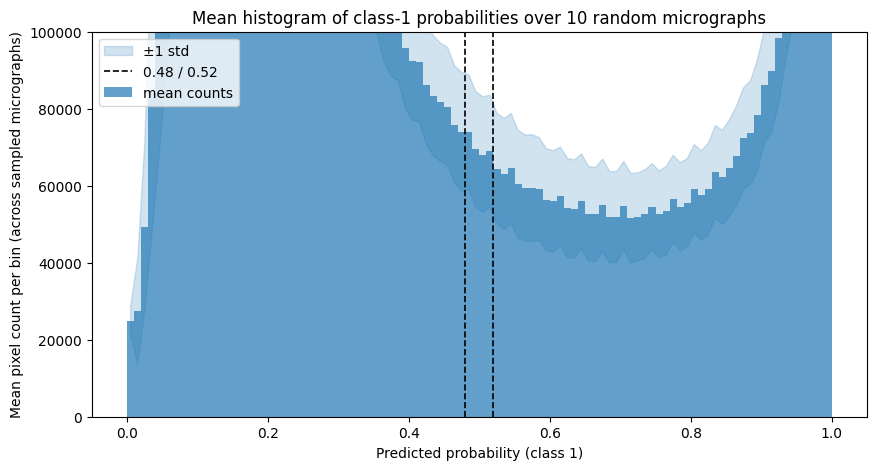

Total pixels in [0.48,0.52] (sum over sampled micrographs): 2805208
Total pixels in [0.40,0.60] (sum over sampled micrographs): 14336364
Ratio [0.48-0.52] / [0.40-0.60] = 0.195671
Baseline = 0.238095
Difference with baseline = -0.042424


In [48]:
a = hist_mask_prob(
     image_dir=IMAGE_DIR,
     label_dir=LABEL_DIR,
     result_dir=RESULT_DIR,
     model_instance=model,
     device=device,
     crop_size=CROP_SIZE,
)

---
### 1-1-2 raw 01 epoch 100 after 02

In [49]:
# @title  { display-mode: "form" }

IMAGE_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/dataset/10017/processed_micrographs_np_split" # @param {type:"string"}
RESULT_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/results_100_CRF/10017/unet_eb5_dice_CRF" # @param {type:"string"}

%cd /content/

/content


Processing sampled micrographs: 100%|██████████| 10/10 [00:35<00:00,  3.56s/it]


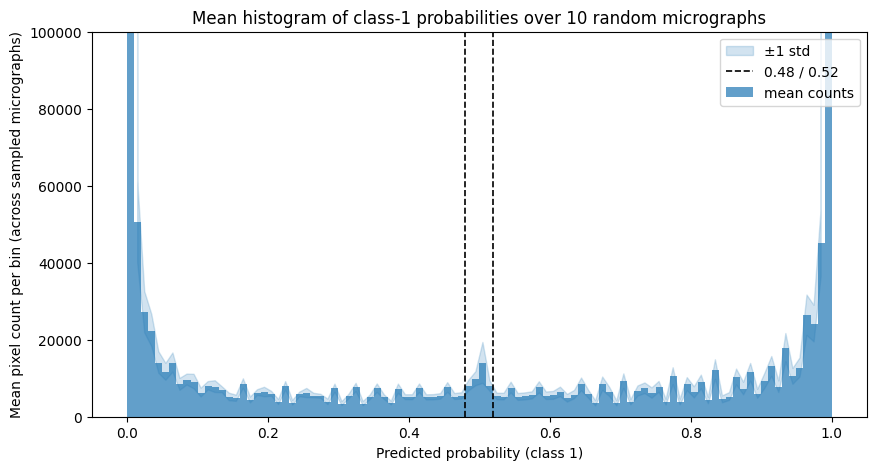

Total pixels in [0.48,0.52] (sum over sampled micrographs): 399452
Total pixels in [0.40,0.60] (sum over sampled micrographs): 1330793
Ratio [0.48-0.52] / [0.40-0.60] = 0.300161
Baseline = 0.238095
Difference with baseline = 0.062066


In [50]:
a = hist_mask_prob(
     image_dir=IMAGE_DIR,
     label_dir=LABEL_DIR,
     result_dir=RESULT_DIR,
     model_instance=model,
     device=device,
     crop_size=CROP_SIZE,
)

---
### 1-2-1 raw 01 epoch 50 before 02

In [51]:
IMAGE_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/dataset/10017/processed_micrographs_np_split" # @param {type:"string"}
RESULT_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/results_50_CRF/10017/unet_eb5_dice" # @param {type:"string"}


Processing sampled micrographs: 100%|██████████| 10/10 [00:35<00:00,  3.59s/it]


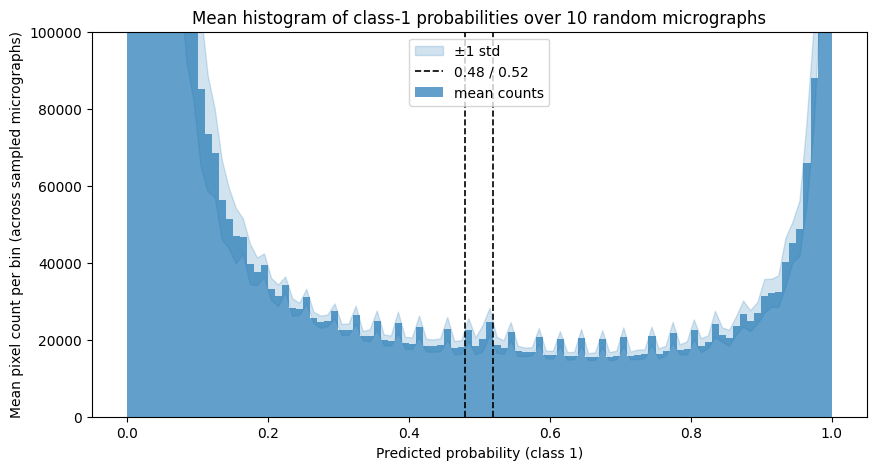

Total pixels in [0.48,0.52] (sum over sampled micrographs): 856534
Total pixels in [0.40,0.60] (sum over sampled micrographs): 3880904
Ratio [0.48-0.52] / [0.40-0.60] = 0.220705
Baseline = 0.238095
Difference with baseline = -0.017390


In [52]:
a = hist_mask_prob(
     image_dir=IMAGE_DIR,
     label_dir=LABEL_DIR,
     result_dir=RESULT_DIR,
     model_instance=model,
     device=device,
     crop_size=CROP_SIZE,
)

---
### 1-2-2 raw 01 epoch 50 after 02

In [53]:
IMAGE_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/dataset/10017/processed_micrographs_np_split" # @param {type:"string"}
RESULT_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/results_50_CRF/10017/unet_eb5_dice_CRF" # @param {type:"string"}


Processing sampled micrographs: 100%|██████████| 10/10 [00:35<00:00,  3.56s/it]


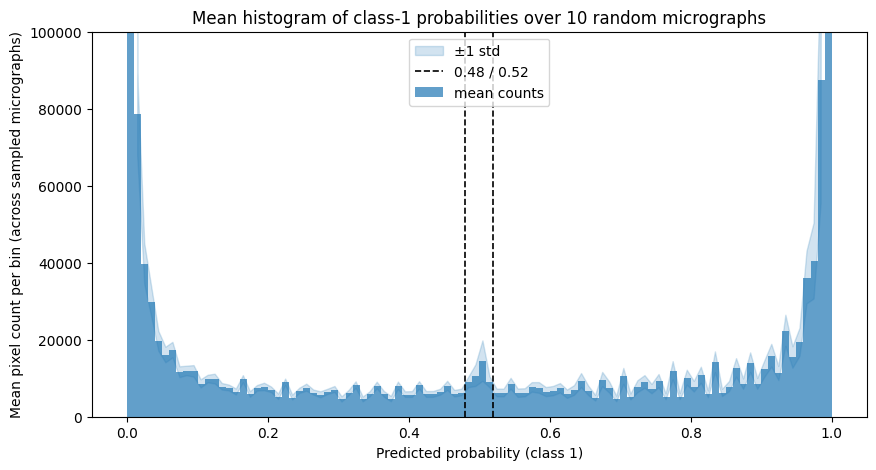

Total pixels in [0.48,0.52] (sum over sampled micrographs): 429686
Total pixels in [0.40,0.60] (sum over sampled micrographs): 1497834
Ratio [0.48-0.52] / [0.40-0.60] = 0.286872
Baseline = 0.238095
Difference with baseline = 0.048776


In [54]:
a = hist_mask_prob(
     image_dir=IMAGE_DIR,
     label_dir=LABEL_DIR,
     result_dir=RESULT_DIR,
     model_instance=model,
     device=device,
     crop_size=CROP_SIZE,
)

---
### 2-1-1 topaz 01 epoch 100 before 02

In [55]:
# @title  { display-mode: "form" }

IMAGE_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/dataset/10017/processed_micrographs_np_split" # @param {type:"string"}
RESULT_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/results_100_CRF/10017/unet_eb5_dice" # @param {type:"string"}

%cd /content/

/content


Processing sampled micrographs: 100%|██████████| 10/10 [01:14<00:00,  7.43s/it]


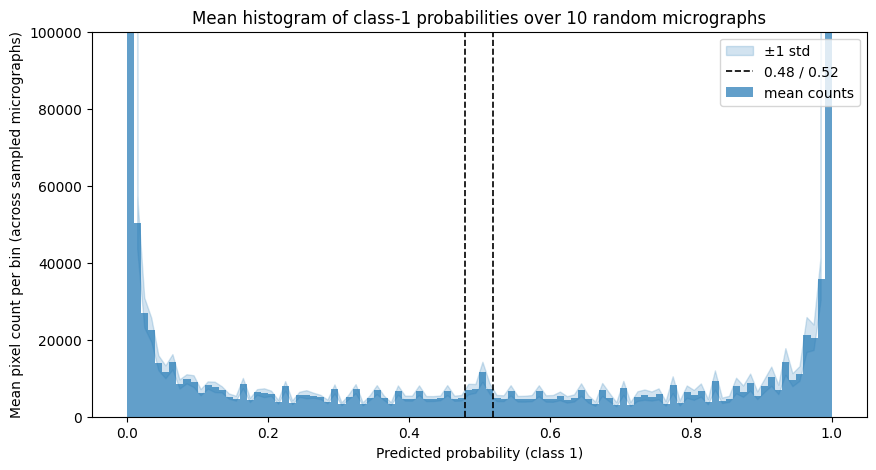

Total pixels in [0.48,0.52] (sum over sampled micrographs): 330628
Total pixels in [0.40,0.60] (sum over sampled micrographs): 1157978
Ratio [0.48-0.52] / [0.40-0.60] = 0.285522
Baseline = 0.238095
Difference with baseline = 0.047427


In [56]:
a = hist_mask_prob(
     image_dir=IMAGE_DIR,
     label_dir=LABEL_DIR,
     result_dir=RESULT_DIR,
     model_instance=model,
     device=device,
     crop_size=CROP_SIZE,
)

---
### 2-1-2 topaz 01 epoch 100 after 02

In [57]:
IMAGE_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/dataset/10017/processed_micrographs_np_split" # @param {type:"string"}
RESULT_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/results_100_CRF/10017/unet_eb5_dice_CRF" # @param {type:"string"}

Processing sampled micrographs: 100%|██████████| 10/10 [00:35<00:00,  3.57s/it]


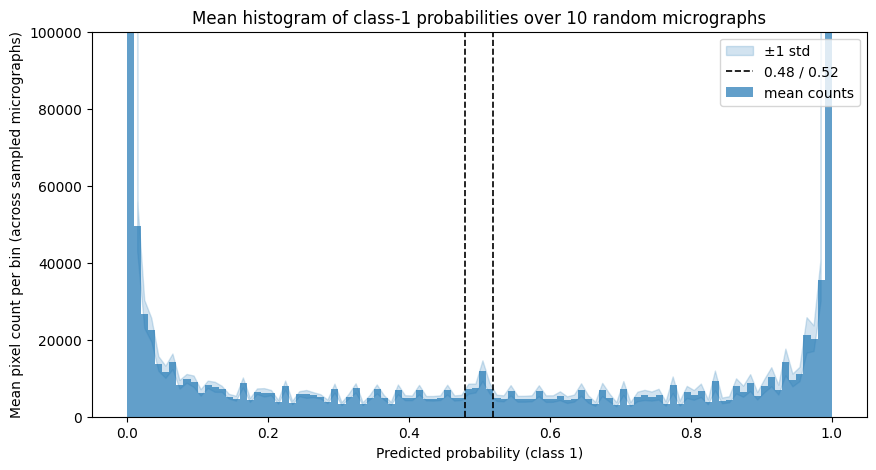

Total pixels in [0.48,0.52] (sum over sampled micrographs): 336105
Total pixels in [0.40,0.60] (sum over sampled micrographs): 1169920
Ratio [0.48-0.52] / [0.40-0.60] = 0.287289
Baseline = 0.238095
Difference with baseline = 0.049194


In [58]:
a = hist_mask_prob(
     image_dir=IMAGE_DIR,
     label_dir=LABEL_DIR,
     result_dir=RESULT_DIR,
     model_instance=model,
     device=device,
     crop_size=CROP_SIZE,
)

---
### 2-2-1 topaz 01 epoch 50 before 02

In [59]:
# @title  { display-mode: "form" }

IMAGE_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/dataset/10017/processed_micrographs_np_split" # @param {type:"string"}
RESULT_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/results_50_CRF/10017/unet_eb5_dice" # @param {type:"string"}

%cd /content/

/content


Processing sampled micrographs: 100%|██████████| 10/10 [00:35<00:00,  3.57s/it]


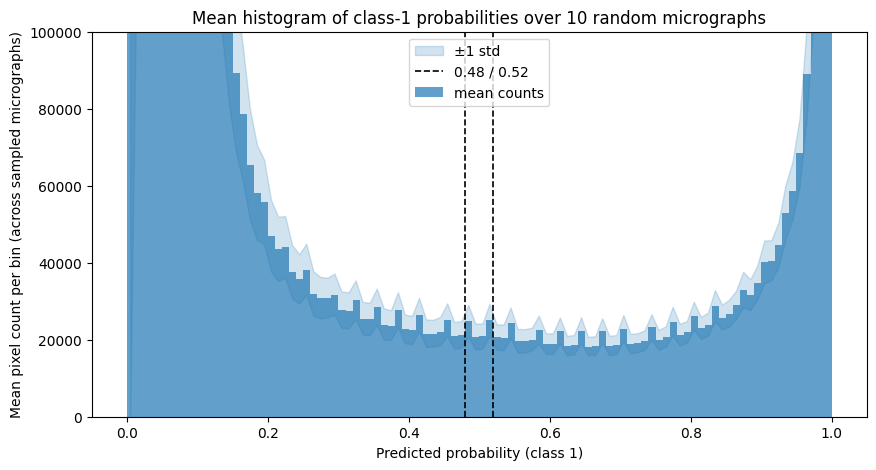

Total pixels in [0.48,0.52] (sum over sampled micrographs): 913773
Total pixels in [0.40,0.60] (sum over sampled micrographs): 4386081
Ratio [0.48-0.52] / [0.40-0.60] = 0.208335
Baseline = 0.238095
Difference with baseline = -0.029761


In [60]:
a = hist_mask_prob(
     image_dir=IMAGE_DIR,
     label_dir=LABEL_DIR,
     result_dir=RESULT_DIR,
     model_instance=model,
     device=device,
     crop_size=CROP_SIZE,
)

---
### 2-2-2 topaz 01 epoch 50 after 02

In [61]:
IMAGE_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/dataset/10017/processed_micrographs_np_split" # @param {type:"string"}
RESULT_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/results_50_CRF/10017/unet_eb5_dice_CRF" # @param {type:"string"}


Processing sampled micrographs: 100%|██████████| 10/10 [00:35<00:00,  3.57s/it]


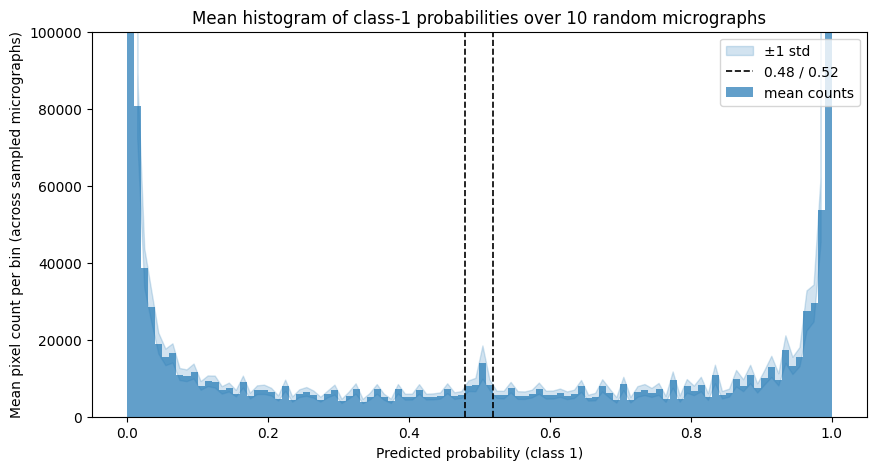

Total pixels in [0.48,0.52] (sum over sampled micrographs): 384167
Total pixels in [0.40,0.60] (sum over sampled micrographs): 1330057
Ratio [0.48-0.52] / [0.40-0.60] = 0.288835
Baseline = 0.238095
Difference with baseline = 0.050740


In [62]:
a = hist_mask_prob(
     image_dir=IMAGE_DIR,
     label_dir=LABEL_DIR,
     result_dir=RESULT_DIR,
     model_instance=model,
     device=device,
     crop_size=CROP_SIZE,
)

---
### 2-3 ESPATIENCE

In [63]:
IMAGE_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/dataset/10017/processed_micrographs_np_split" # @param {type:"string"}
RESULT_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/results_100_ESPatience_50_CRF/10017/unet_eb5_dice_CRF" # @param {type:"string"}


Processing sampled micrographs: 100%|██████████| 10/10 [00:35<00:00,  3.56s/it]


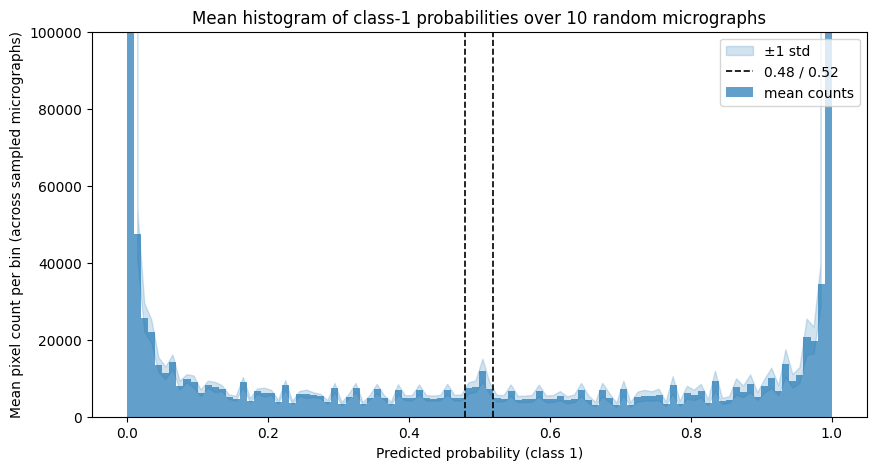

Total pixels in [0.48,0.52] (sum over sampled micrographs): 344657
Total pixels in [0.40,0.60] (sum over sampled micrographs): 1183248
Ratio [0.48-0.52] / [0.40-0.60] = 0.291280
Baseline = 0.238095
Difference with baseline = 0.053185


In [64]:
a = hist_mask_prob(
     image_dir=IMAGE_DIR,
     label_dir=LABEL_DIR,
     result_dir=RESULT_DIR,
     model_instance=model,
     device=device,
     crop_size=CROP_SIZE,
)

---

CDCRF

In [65]:
IMAGE_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/dataset/10017/processed_micrographs_np_split" # @param {type:"string"}
RESULT_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/results/10017/unet_eb5_dice_CDCRF" # @param {type:"string"}

Processing sampled micrographs: 100%|██████████| 10/10 [00:35<00:00,  3.56s/it]


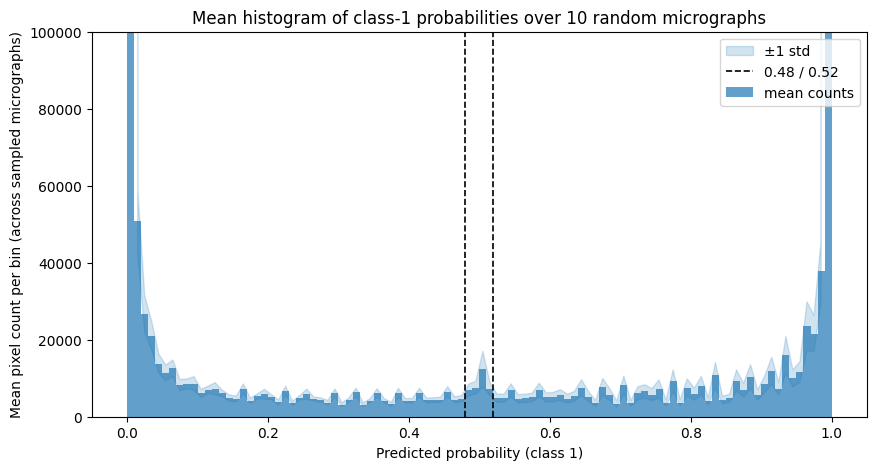

Total pixels in [0.48,0.52] (sum over sampled micrographs): 341097
Total pixels in [0.40,0.60] (sum over sampled micrographs): 1159808
Ratio [0.48-0.52] / [0.40-0.60] = 0.294098
Baseline = 0.238095
Difference with baseline = 0.056003


In [66]:
a = hist_mask_prob(
     image_dir=IMAGE_DIR,
     label_dir=LABEL_DIR,
     result_dir=RESULT_DIR,
     model_instance=model,
     device=device,
     crop_size=CROP_SIZE,
)

---

with different split process

In [67]:
IMAGE_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/TpzD_default_output/dataset/10017/processed_micrographs_np_split" # @param {type:"string"}
RESULT_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/TpzD_default_output/results/10017/unet_eb5_dice" # @param {type:"string"}

Processing sampled micrographs: 100%|██████████| 10/10 [01:10<00:00,  7.05s/it]


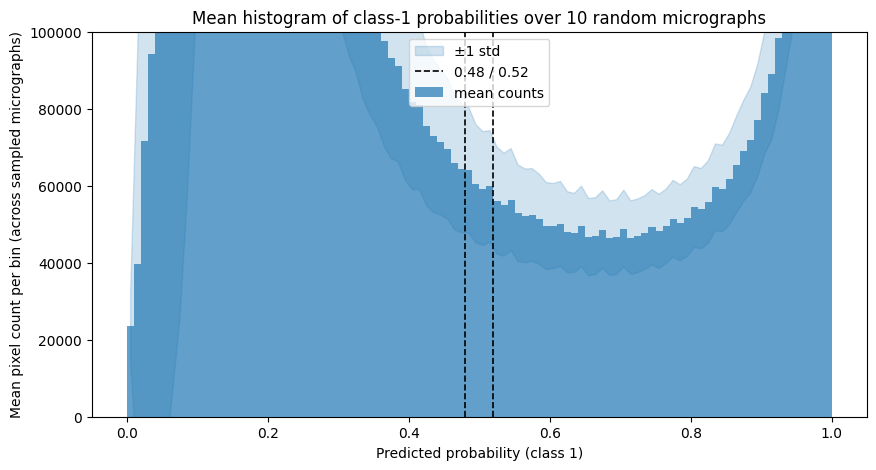

Total pixels in [0.48,0.52] (sum over sampled micrographs): 2436538
Total pixels in [0.40,0.60] (sum over sampled micrographs): 12514556
Ratio [0.48-0.52] / [0.40-0.60] = 0.194696
Baseline = 0.238095
Difference with baseline = -0.043399


In [68]:
a = hist_mask_prob(
     image_dir=IMAGE_DIR,
     label_dir=LABEL_DIR,
     result_dir=RESULT_DIR,
     model_instance=model,
     device=device,
     crop_size=CROP_SIZE,
)

another cdcrf TpzD_default_output

In [69]:
IMAGE_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/TpzD_default_output/dataset/10017/processed_micrographs_np_split" # @param {type:"string"}
RESULT_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/TpzD_default_output/results/10017/unet_eb5_dice_CDCRF" # @param {type:"string"}

Processing sampled micrographs: 100%|██████████| 10/10 [00:35<00:00,  3.57s/it]


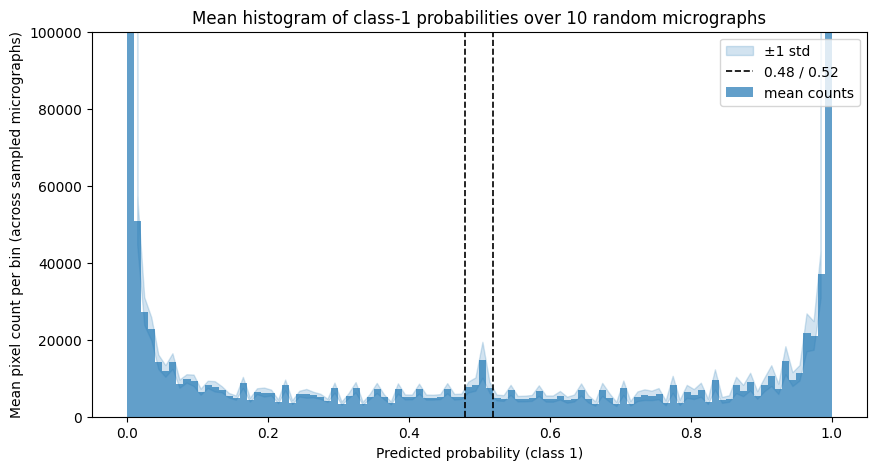

Total pixels in [0.48,0.52] (sum over sampled micrographs): 381078
Total pixels in [0.40,0.60] (sum over sampled micrographs): 1243175
Ratio [0.48-0.52] / [0.40-0.60] = 0.306536
Baseline = 0.238095
Difference with baseline = 0.068441


In [70]:
a = hist_mask_prob(
     image_dir=IMAGE_DIR,
     label_dir=LABEL_DIR,
     result_dir=RESULT_DIR,
     model_instance=model,
     device=device,
     crop_size=CROP_SIZE,
)

---
### 3-1-1 segnet 01 epoch 100 before 02

In [71]:
# @title  { display-mode: "form" }

IMAGE_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/C_CSN_D_float_u_output/dataset/10017/processed_micrographs_np_split" # @param {type:"string"}
RESULT_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/C_CSN_D_float_u_output/results_100_CRF/10017/unet_eb5_dice" # @param {type:"string"}

%cd /content/

/content


Processing sampled micrographs: 100%|██████████| 10/10 [00:48<00:00,  4.88s/it]


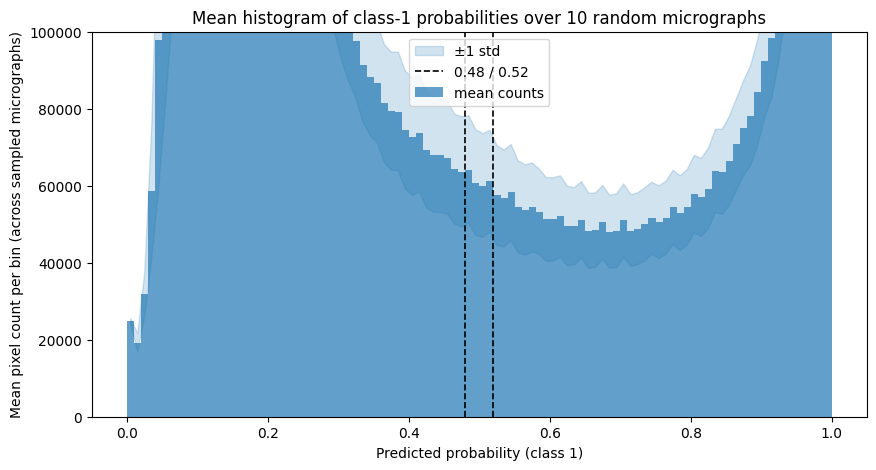

Total pixels in [0.48,0.52] (sum over sampled micrographs): 2462684
Total pixels in [0.40,0.60] (sum over sampled micrographs): 12326378
Ratio [0.48-0.52] / [0.40-0.60] = 0.199790
Baseline = 0.238095
Difference with baseline = -0.038305


In [72]:
a = hist_mask_prob(
     image_dir=IMAGE_DIR,
     label_dir=LABEL_DIR,
     result_dir=RESULT_DIR,
     model_instance=model,
     device=device,
     crop_size=CROP_SIZE,
)

---
### 3-1-2 segnet 01 epoch 100 after 02

In [73]:
IMAGE_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/C_CSN_D_float_u_output/dataset/10017/processed_micrographs_np_split" # @param {type:"string"}
RESULT_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/C_CSN_D_float_u_output/results_100_CRF/10017/unet_eb5_dice_CRF" # @param {type:"string"}


Processing sampled micrographs: 100%|██████████| 10/10 [00:35<00:00,  3.59s/it]


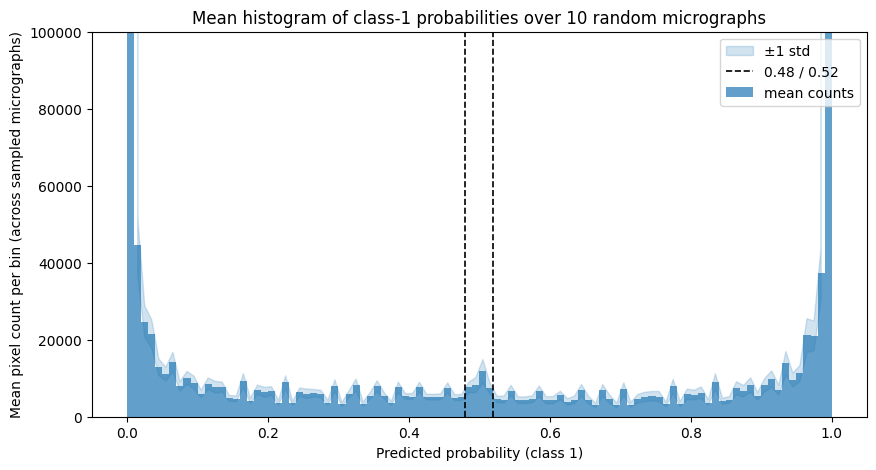

Total pixels in [0.48,0.52] (sum over sampled micrographs): 350322
Total pixels in [0.40,0.60] (sum over sampled micrographs): 1204464
Ratio [0.48-0.52] / [0.40-0.60] = 0.290853
Baseline = 0.238095
Difference with baseline = 0.052758


In [74]:
a = hist_mask_prob(
     image_dir=IMAGE_DIR,
     label_dir=LABEL_DIR,
     result_dir=RESULT_DIR,
     model_instance=model,
     device=device,
     crop_size=CROP_SIZE,
)

---
### 3-2-1 segnet 01 epoch 50 before 02

In [75]:
# @title  { display-mode: "form" }

IMAGE_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/C_CSN_D_float_u_output/dataset/10017/processed_micrographs_np_split" # @param {type:"string"}
RESULT_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/C_CSN_D_float_u_output/results_50_CRF/10017/unet_eb5_dice" # @param {type:"string"}

%cd /content/

/content


Processing sampled micrographs: 100%|██████████| 10/10 [00:35<00:00,  3.57s/it]


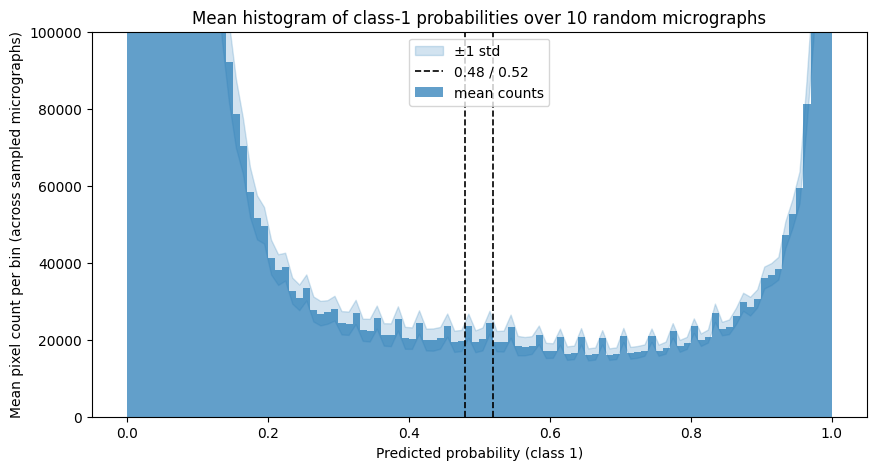

Total pixels in [0.48,0.52] (sum over sampled micrographs): 874520
Total pixels in [0.40,0.60] (sum over sampled micrographs): 4107868
Ratio [0.48-0.52] / [0.40-0.60] = 0.212889
Baseline = 0.238095
Difference with baseline = -0.025206


In [76]:
a = hist_mask_prob(
     image_dir=IMAGE_DIR,
     label_dir=LABEL_DIR,
     result_dir=RESULT_DIR,
     model_instance=model,
     device=device,
     crop_size=CROP_SIZE,
)

---
### 3-2-2 segnet 01 epoch 50 after 02

In [77]:
IMAGE_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/C_CSN_D_float_u_output/dataset/10017/processed_micrographs_np_split" # @param {type:"string"}
RESULT_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/C_CSN_D_float_u_output/results_50_CRF/10017/unet_eb5_dice_CRF" # @param {type:"string"}


Processing sampled micrographs: 100%|██████████| 10/10 [00:35<00:00,  3.58s/it]


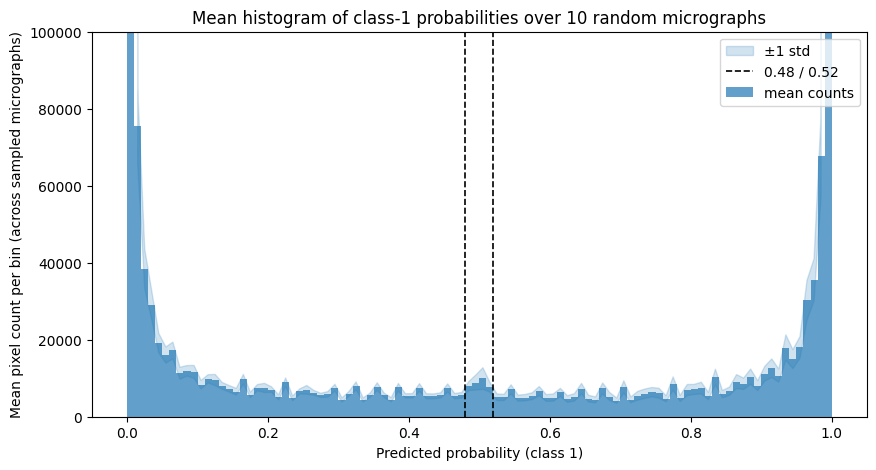

Total pixels in [0.48,0.52] (sum over sampled micrographs): 344526
Total pixels in [0.40,0.60] (sum over sampled micrographs): 1257839
Ratio [0.48-0.52] / [0.40-0.60] = 0.273903
Baseline = 0.238095
Difference with baseline = 0.035808


In [78]:
a = hist_mask_prob(
     image_dir=IMAGE_DIR,
     label_dir=LABEL_DIR,
     result_dir=RESULT_DIR,
     model_instance=model,
     device=device,
     crop_size=CROP_SIZE,
)